
<table width="100%">
  <td style="font-size:30px;text-align:left;background-color:rgba(150, 123, 182, 0.7);font-style:italic;">
    Simon's algorithm.<br>
    <span style="font-size:25px;font-style:normal;">
    Borja Álvarez Reguera & Alicia de la Varga Cabero.
    </span>
  </td>
</table>

<p style="font-size:22px; font-weight:bold;">Simon's algorithm.</p>

The **Simon's algorithm** is a fundamental quantum algorithm demonstrating an **exponential speedup** over classical algorithms for a specific problem, the first one to have real-world implications.  
It is designed to find a hidden **binary string** $s \in \{0,1\}^n$ such that a given function $f: \{0,1\}^n \rightarrow \{0,1\}^n$ satisfies:

$$
f(x) = f(y) \iff y = x \oplus s,
$$

where $\oplus$ denotes bitwise XOR. The goal is to **determine the hidden string $s$**.

Classically, solving this problem requires exponentially many queries $\left( O(2^\frac{n}{2}) \right)$ in the worst case, while Simon's quantum algorithm can find $s$ **using only $\mathcal{O}(n)$ queries** by exploiting **superposition**, **entanglement**, and **interference**.

In this task, we will:
- Implement a **Simon oracle** $U_f$ that encodes the function $f(x)$ with the hidden XOR string $s$.
- Build a **Simon's algorithm wrapper function** that prepares the circuit, applies the oracle, measures the input q-bits to extract linear equations for $s$ and solves them.
- Test the algorithm with multiple hidden strings $s$ of different lengths $n$, and interpret the measurement outcomes to recover $s$.


In [1]:
# Import packages & classes
    # Classical Python Packages
import numpy as np
import matplotlib.pyplot as plt
    # Qiskit tools :)
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

<p style="font-size:18px; font-weight:bold;">Oracle construction.</p>

In this section, we build the **Simon oracle** $U_f$ corresponding to a function $f : \{0,1\}^n \rightarrow \{0,1\}^n$ with a hidden XOR string $s \in \{0,1\}^n$. The oracle acts on computational basis states as  

$$
U_f |x\rangle|y\rangle = |x\rangle |y \oplus f(x)\rangle,
$$

where the second register consists of $n$ ancilla q-bits initialized to $|0\rangle$ and $\oplus$ denotes bitwise XOR. The oracle function should satisfy the following promise:

$$
f(x) = f(y) \iff y = x \oplus s.
$$

This encoding ensures that the hidden string $s$ is embedded in the correlations between inputs: pairs of inputs differing by $s$ produce the same output.

In our implementation:

1. **Preparation of registers:** We create $n$ input q-bits and $n$ ancilla q-bits initialized to $|0\rangle$.
2. **Mapping inputs to outputs:** For each computational basis state $|x\rangle$, we first apply $X$ gates to transform $|x\rangle$ to $|11\dots1\rangle$, which simplifies controlled operations.
3. **Copying $f(x)$ to the ancilla:** We use controlled-NOT gates from the input register to the ancilla q-bits according to the bits of $f(x)$, effectively implementing $|x\rangle|0\rangle \mapsto |x\rangle|f(x)\rangle$.
4. **Reversing the initial transformation:** Finally, we undo the initial $X$ gates so that the input register returns to $|x\rangle$ while the ancilla encodes $f(x)$.

This construction generates a general Simon oracle capable of representing *any* function with a hidden string $s$, enabling the Simon algorithm to extract $s$ via quantum interference.


In [2]:
def oracle(qc, f, n):
    """
    Build the Simon oracle for a hidden string s using the function f.
    It implements f: {0,1}^n -> {0,1}^n such that f(x) = f(y) iff y = x + s.
    
    Parameters:
        qc (QuantumCircuit): The quantum circuit.
        f (function): Classical function implementing Simon's f(x).
        n (int): Number of input q-bits (assume n ancilla q-bits as output).
    """
    for x in range(2**n):
        x_bits, fx_bits = format(x, f'0{n}b'), format(f(x), f'0{n}b')
        
        # Prepare |x> -> |11...1> with X gates
        for i, bit in enumerate(x_bits):
            if bit == '0': qc.x(i)

        # Copy f(x) into ancilla
        for j, bit in enumerate(fx_bits):
            if bit == '1': qc.mcx(list(range(n)), n+j)

        # Undo initial X gates
        for i, bit in enumerate(x_bits):
            if bit == '0': qc.x(i)

<p style="font-size:18px; font-weight:bold;">Auxiliary functions.</p>

To implement Simon's algorithm cleanly, we introduce two **auxiliary functions**:

1. **`check_simon_property(f, n)`**  
   This function verifies that the given function $f:\{0,1\}^n \to \{0,1\}^n$ satisfies **Simon's promise**:  
   - $f$ is **2-to-1**, meaning each output value occurs for exactly two distinct inputs.  
   - There exists a **secret string** $s \neq 0$ such that $f(x) = f(y)$ if and only if $y = x \oplus s$.  

   The function iterates over all $2^n$ inputs, collects outputs, and checks:
   $$
   \forall y \in \text{range}(f), \quad |\{ x \mid f(x) = y \}| = 2
   $$
   and that the XOR differences between each pair of inputs with the same output are consistent, giving the unique hidden string $s$.

2. **`solve_linear_mod2(Y)`**  
   After running the quantum circuit several times, we collect a set of measured bitstrings forming a linear system:
   $$
   Y \cdot s = 0 \pmod 2
   $$
   where each row of $Y$ is a bitstring obtained from measuring the first register.  

   This function solves the system using **Gaussian elimination over GF(2)** to recover a nonzero solution $s$ corresponding to the hidden string of Simon's problem.  

Together, these two functions allow the main `simon_run` function to:
- First **validate** the function $f$ and extract the secret string $s$ (for verification or debugging).  
- Then **compute** $s$ from the measurement outcomes obtained from the quantum circuit.

In [3]:
def check_simon_property(f, n):
    """
    Checks whether f satisfies Simon's promise: f(x) = f(x + s)
    for some nonzero s, and is 2-to-1.

    Parameters:
        f (function): Boolean function {0,1}^n -> {0,1}^n (as integer)
        n (int): Number of input q-bits

    Returns:
        s_candidate (int or None): Secret string s as integer if valid, else None
    """
    outputs = {}
    
    for x in range(2**n):
        fx = f(x)
        if not (0 <= fx <= 2**n - 1):
            raise ValueError(f"Output f({x}) = {fx} is out of the allowed range [0, {2**n - 1}]")
        outputs.setdefault(fx, []).append(x)

    # Each output should have exactly 2 inputs
    for fx, xs in outputs.items():
        if len(xs) != 2:
            print(f"f is not 2-to-1: output {fx} has {len(xs)} inputs")
            return None

    # Check that all XOR differences are the same (s is consistent)
    s_candidate = None
    for xs in outputs.values():
        x1, x2 = xs
        s = x1 ^ x2
        if s_candidate is None:
            s_candidate = s
        elif s_candidate != s:
            print(f"Inconsistent secret s: {format(s_candidate, f'0{n}b')} vs {format(s, f'0{n}b')}")
            return None

    print(f"Function satisfies Simon's promise with s = {format(s_candidate, f'0{n}b')}")
    return s_candidate

def solve_linear_mod2(Y):
    """
    Solve Y s = 0 (mod 2) for s != 0 using row reduction over GF(2).

    Parameters:
        Y (ndarray): 2D array of shape (m, n) with linearly independent measurement vectors

    Returns:
        s (str): Nonzero solution as bitstring
    """
    Y = Y.copy()
    m, n = Y.shape

    # Gaussian elimination modulo 2
    row = 0
    for col in range(n):
        pivot_rows = np.where(Y[row:, col] == 1)[0]
        if len(pivot_rows) == 0:
            continue
        pivot = pivot_rows[0] + row
        Y[[row, pivot]] = Y[[pivot, row]]
        for r in range(m):
            if r != row and Y[r, col] == 1:
                Y[r] = (Y[r] + Y[row]) % 2
        row += 1

    # Now find the nullspace: set the first free variable to 1
    # All variables that were not a pivot are free
    pivot_cols = []
    row = 0
    for col in range(n):
        if row < m and Y[row, col] == 1:
            pivot_cols.append(col)
            row += 1
    free_cols = [i for i in range(n) if i not in pivot_cols]

    # There should be exactly one free variable (the hidden string)
    s = np.zeros(n, dtype=int)
    if len(free_cols) != 1:
        raise ValueError("Unexpected number of free variables; check Y")
    s[free_cols[0]] = 1

    # Back-substitute to get remaining bits
    for r, col in reversed(list(enumerate(pivot_cols))):
        s[col] = sum(Y[r, free_cols] * s[free_cols]) % 2

    return ''.join(str(b) for b in s)

<p style="font-size:18px; font-weight:bold;">Algorithm outline & implementation.</p>

The algorithm proceeds as follows:

1. **Validation**  
   We first check that $f$ satisfies Simon's promise using `check_simon_property(f, n)`. This ensures that $f$ is 2-to-1 and consistent with a hidden string $s$.

2. **Initialization and Superposition**  
   Create a quantum circuit with two registers: $n$ input q-bits and $n$ ancilla q-bits. Apply Hadamard gates to the input q-bits to generate a uniform superposition over all input states.

3. **Oracle Application**  
   Apply the Simon oracle, which maps $|x\rangle|0\rangle \mapsto |x\rangle|f(x)\rangle$. This encodes correlations between inputs differing by $s$.

4. **Interference**  
   Apply Hadamard gates again to the input register. Interference patterns now encode linear equations of the form
   $$
   y \cdot s = 0 \pmod 2
   $$
   where $y$ is the measured input string.

5. **Measurement**  
   Measure the input q-bits. Repeat until we have $n-1$ independent measurements forming a linear system modulo 2.

6. **Classical Post-Processing**  
   Use `solve_linear_mod2(Y)` to solve the system and extract the hidden string $s$.

The full `simon_run` function implements these steps, combining quantum measurement with classical linear algebra to recover $s$ efficiently.


In [4]:
def simon_run(f, n):
    """
    Runs Simon's algorithm for a given function f and n input q-bits.
    Collects linearly independent measurements to deterministically recover s.

    Parameters:
        f (function): A Boolean function f: {0,1}^n -> {0,1}^n satisfying Simon's promise.
        n (int): Number of input q-bits.

    Returns:
        qc (QuantumCircuit): The final quantum circuit.
        measurements (list of str): Distinct linearly independent measurement outcomes.
        s_found (str): Hidden string discovered by Simon's algorithm.
    """

    # --- Step 0: Check Simon's promise ---
    s_true = check_simon_property(f, n)
    if s_true is None:
        raise ValueError("Function f does not satisfy Simon's promise. Cannot proceed.")

    # --- Step 1: Build the quantum circuit ---
    qc = QuantumCircuit(2*n, n)  # n input + n ancilla, n classical for input

    # Apply Hadamard gates to input q-bits
    for i in range(n):
        qc.h(i)
    qc.barrier()

    # --- Step 2: Apply the oracle ---
    oracle(qc, f, n)
    qc.barrier()

    # --- Step 3: Apply Hadamard again to input q-bits ---
    for i in range(n):
        qc.h(i)

    # --- Step 4: Measure input q-bits ---
    for i in range(n):
        qc.measure(i, i)

    # --- Step 5: Collect linearly independent measurements ---
    simulator = AerSimulator()
    measurements = []
    Y = np.empty((0, n), dtype=int)  # matrix to store measurements

    while Y.shape[0] < n-1:
        counts = simulator.run(qc, shots=1).result().get_counts()
        bitstring = list(counts.keys())[0][::-1]  # invert for indexing
        vec = np.array([int(b) for b in bitstring], dtype=int)

        # Check if vec is linearly independent of Y
        if np.any(vec):
            if Y.shape[0] == 0:
                Y = np.vstack([Y, vec])
                measurements.append(bitstring)
            else:
                combined = np.vstack([Y, vec])
                if np.linalg.matrix_rank(combined % 2) > np.linalg.matrix_rank(Y % 2):
                    Y = combined
                    measurements.append(bitstring)

    # --- Step 6: Solve Y s = 0 mod 2 ---
    s_found = solve_linear_mod2(Y)

    print(f"Hidden string found by Simon's algorithm: {s_found}")
    display(qc.draw('mpl'))

    return qc, measurements, Y

<p style="font-size:18px; font-weight:bold;">Testing Simon's Algorithm.</p>

Now that the Simon algorithm, its oracle, and the auxiliary functions have been implemented, it is time to verify that everything works as expected.

We will test several functions $f:\{0,1\}^n \to \{0,1\}^n$ satisfying Simon's promise, as well as a few invalid cases to check that input validation works correctly.

Test cases:

1. **Valid 2-to-1**
   Example: $n=2$, hidden string $s = 10$, define $f(x)$ such that $f(x) = f(x \oplus s)$.

3. **Valid 2-to-1**
   Example: $n=3$, hidden string $s = 011$.

5. **Valid 2-to-1** 
   Example: $n=4$, hidden string $s = 1011$.

6. **Invalid function (output not in range)**
   Example: returns an output that exceeds $2^n -1$.
   
7. **Invalid function (not 2-to-1)**  
   Example: returns the same output for more than two inputs or inconsistent XOR differences. 

8. **Invalid function (inconsistent key)**
   Example: is 2-to-1 but inputs with the same output don't share the same key.
   

Expected behavior:

- For valid functions, `simon_run(f, n)` should:
  - Verify the function satisfies Simon's promise.
  - Build and simulate the quantum circuit.
  - Collect enough linearly independent measurements to solve $Y \cdot s = 0 \pmod 2$.
  - Recover the correct hidden string $s$.


- For invalid functions, `check_simon_property(f, n)` should:
  - Print a message indicating why the function does not satisfy Simon's promise.
  - Raise an error or return `None`, preventing the quantum circuit from being built.

By running these tests, we can confirm both the **function validation** and the **algorithm implementation** behave correctly.


--- Testing: Valid 2-to-1, s=10, n=2 ---
Function satisfies Simon's promise with s = 10
Hidden string found by Simon's algorithm: 10


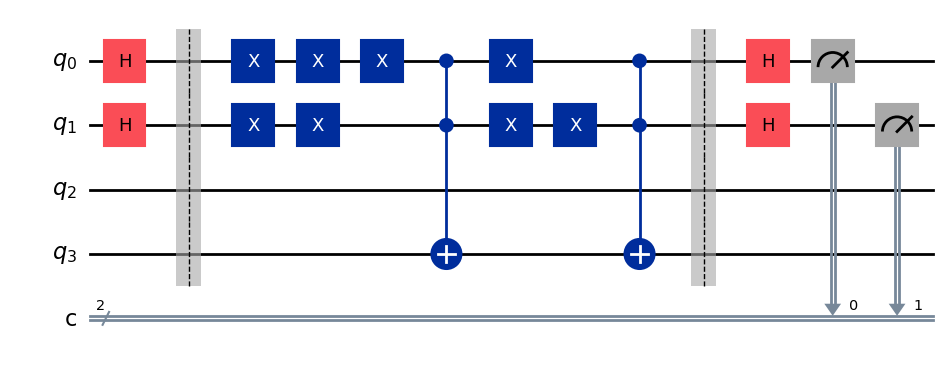


--- Testing: Valid 2-to-1, s=011, n=3 ---
Function satisfies Simon's promise with s = 011
Hidden string found by Simon's algorithm: 011


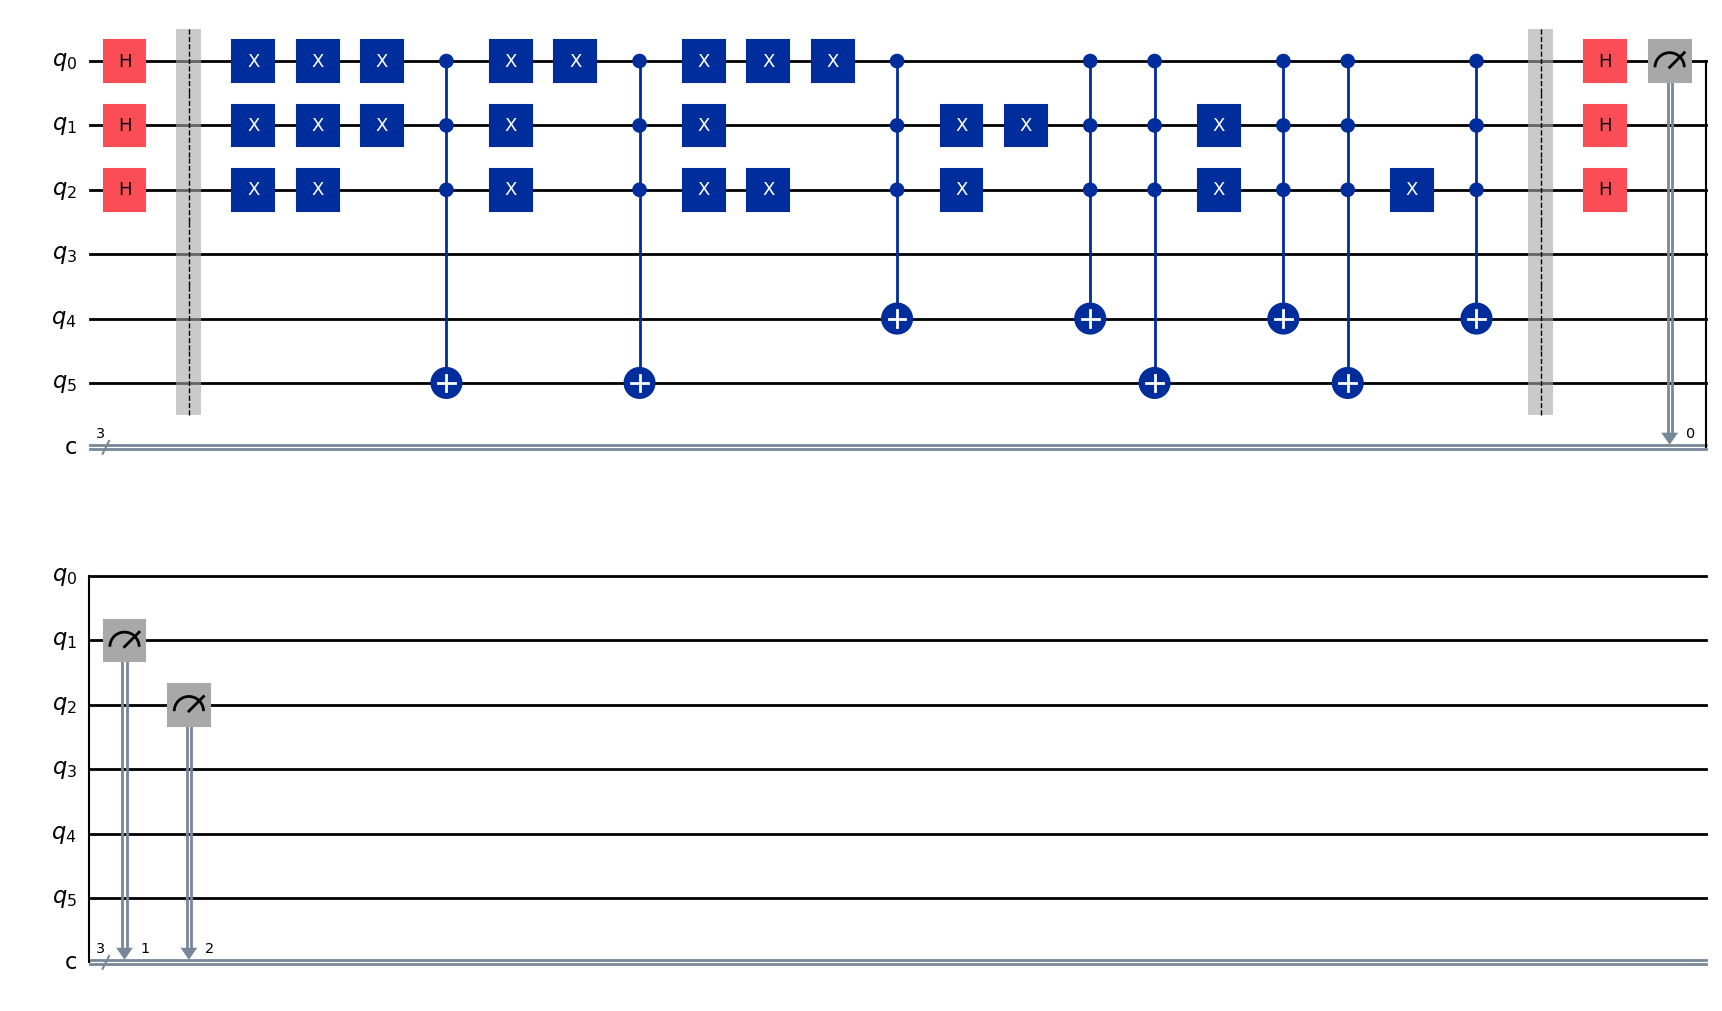


--- Testing: Valid 2-to-1, s=1011, n=4 ---
Function satisfies Simon's promise with s = 1011
Hidden string found by Simon's algorithm: 1011


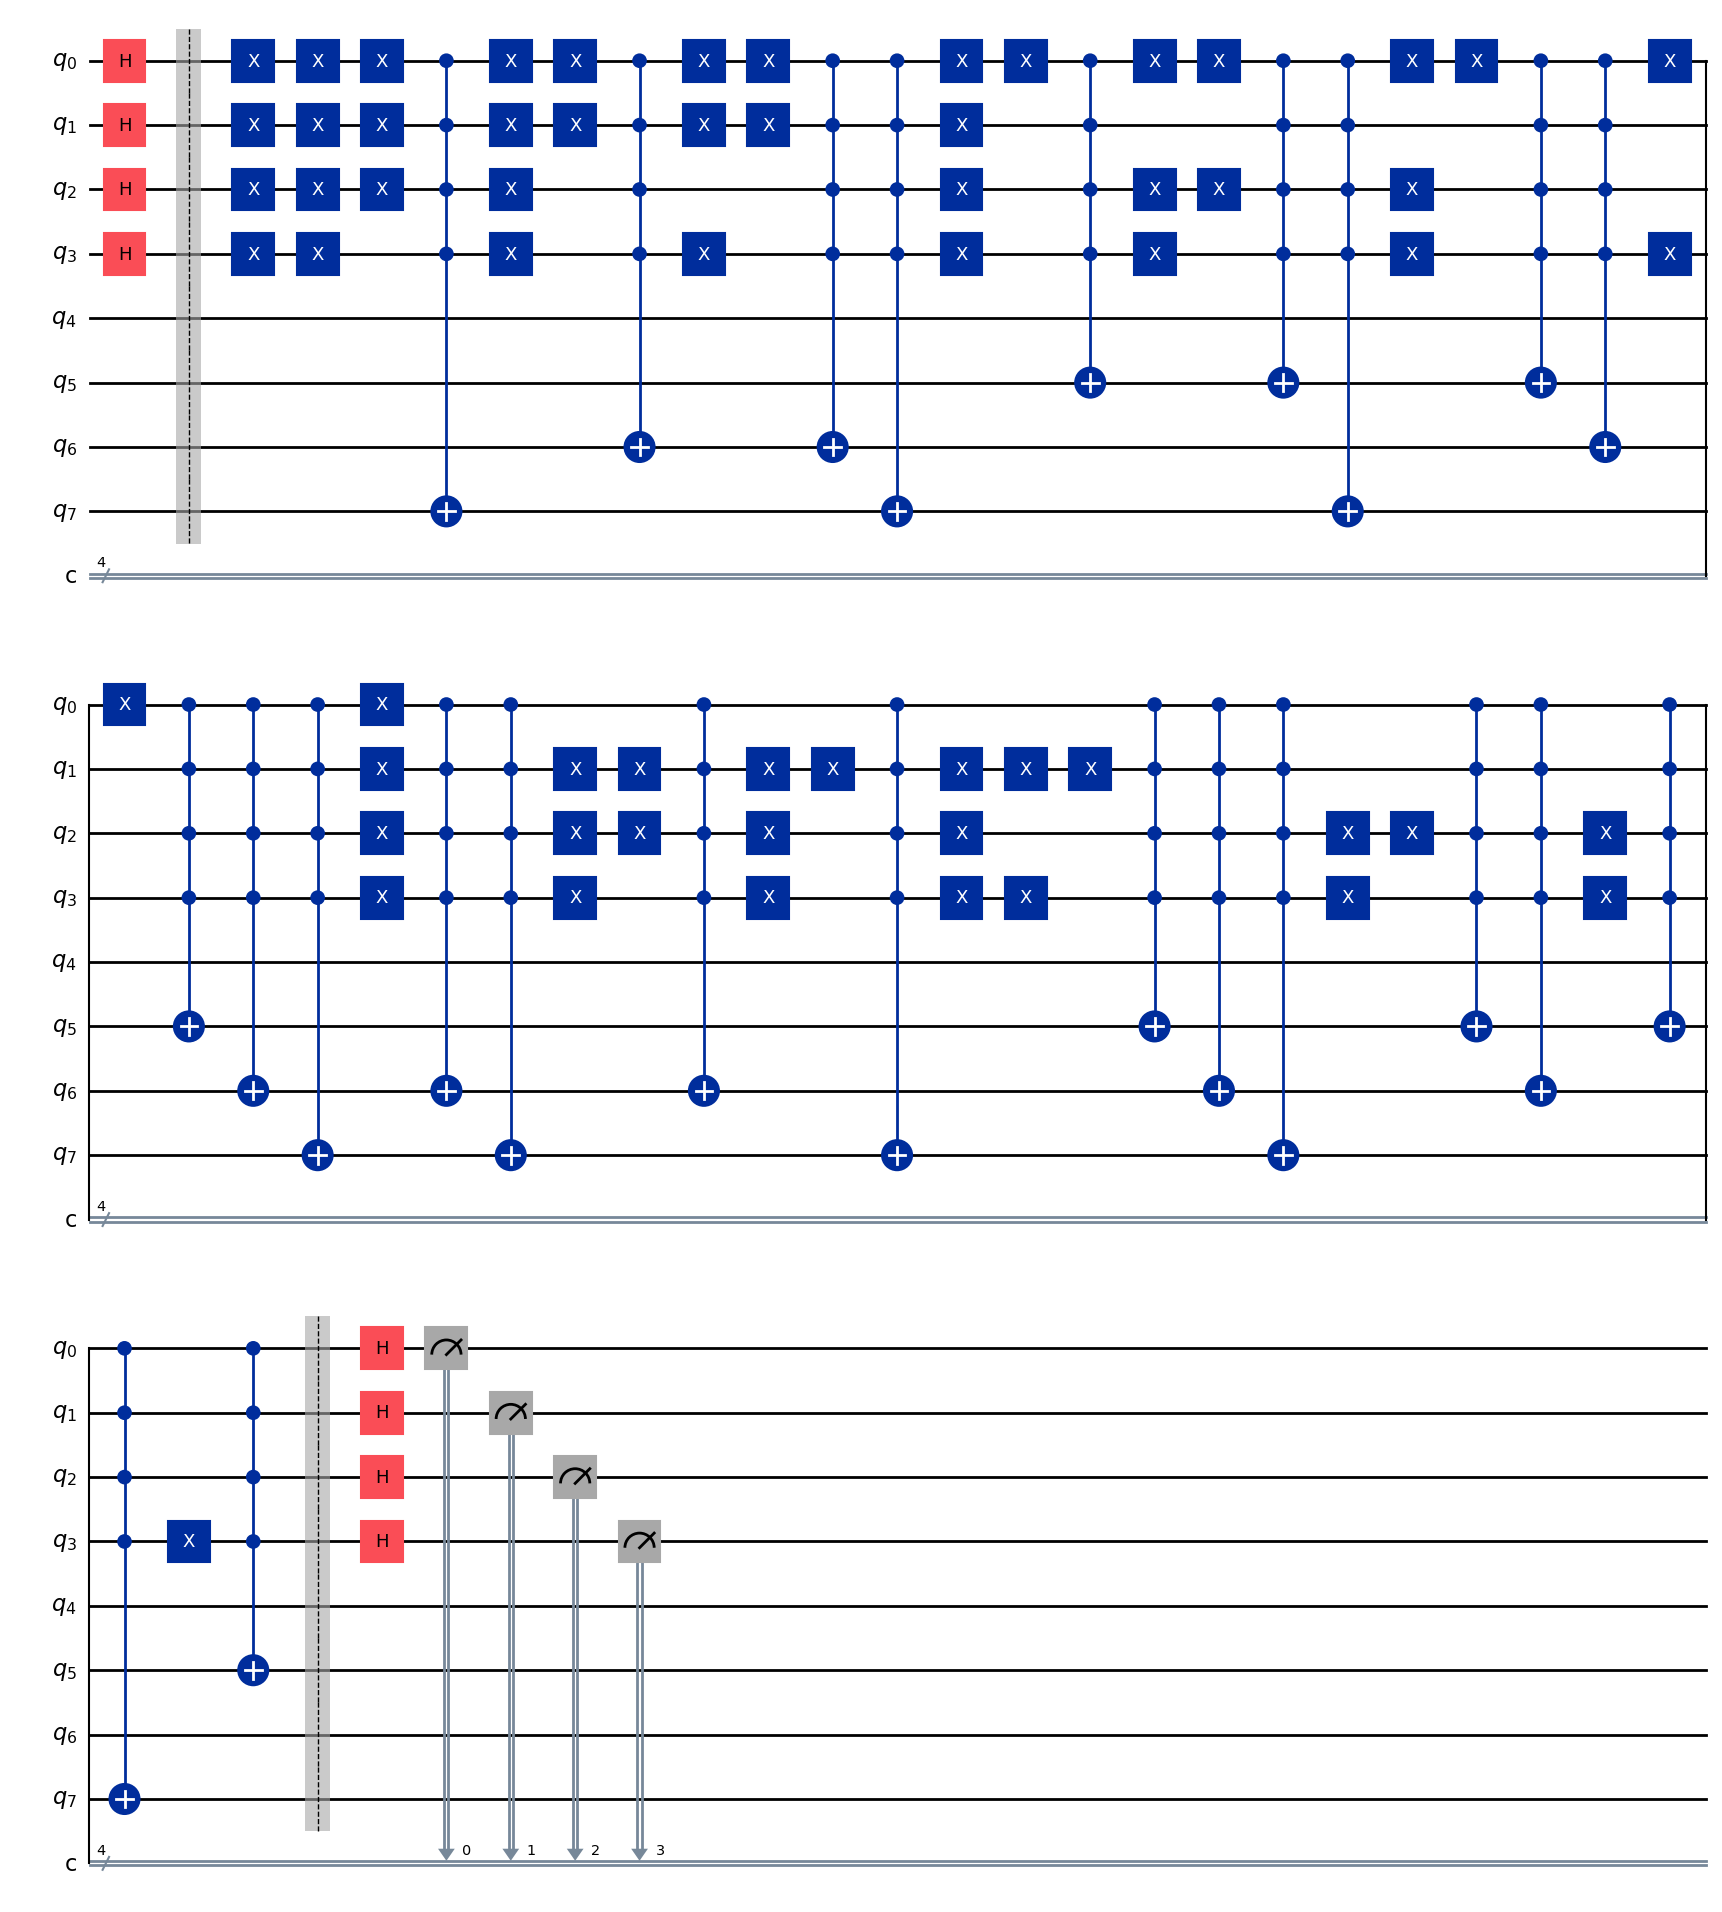


--- Testing: Invalid function (not in range [0, 2^n - 1], n=3 ---
Error detected: Output f(0) = 8 is out of the allowed range [0, 7]

--- Testing: Invalid function (not 2-to-1), n=3 ---
f is not 2-to-1: output 0 has 3 inputs
Error detected: Function f does not satisfy Simon's promise. Cannot proceed.

--- Testing: Invalid function (no consistent key), n=3 ---
Inconsistent secret s: 001 vs 110
Error detected: Function f does not satisfy Simon's promise. Cannot proceed.


In [5]:
# --- Define test functions for Simon's algorithm ---

# 1. Valid 2-to-1 function, n=2, hidden string s=10
def f_valid_1(x):
    if x in [0, 2]: return 0
    if x in [1, 3]: return 1

# 2. Valid 2-to-1 function, n=3, hidden string s=011
def f_valid_2(x):
    if x in [0, 3]: return 0
    if x in [1, 2]: return 1
    if x in [4, 7]: return 2
    if x in [5, 6]: return 3

# 3. Valid 2-to-1 function, n=4, hidden string s=1011
def f_valid_3(x):
    if x in [0, 11]: return 0
    if x in [1, 10]: return 1
    if x in [2, 9]:  return 2
    if x in [3, 8]:  return 3
    if x in [4, 15]: return 4
    if x in [5, 14]: return 5
    if x in [6, 13]: return 6
    if x in [7, 12]: return 7

# 4. Invalid function (output not in range [0, 2^n -1])
def f_invalid_range(x):
    if x in [0, 4]: return 8
    if x in [1, 5]: return 3
    if x in [2, 6]: return 4
    if x in [3, 7]: return 1

# 5. Invalid function (not 2-to-1), n=3
def f_invalid_2to1(x):
    if x in [0, 1, 2]: return 0  # three inputs map to same output
    if x in [3, 4]: return 1
    if x in [5, 6, 7]: return 2  # inconsistent

# 6. Invalid function (no consistent key), n=3
def f_invalid_key(x):
    if x in [0, 1]: return 0
    if x in [2, 4]: return 1
    if x in [3, 5]: return 2
    if x in [6, 7]: return 3  


# --- Define test cases ---
test_cases = [
    (f_valid_1, 2, "Valid 2-to-1, s=10"),
    (f_valid_2, 3, "Valid 2-to-1, s=011"),
    (f_valid_3, 4, "Valid 2-to-1, s=1011"),
    (f_invalid_range, 3, "Invalid function (not in range [0, 2^n - 1]"),
    (f_invalid_2to1, 3, "Invalid function (not 2-to-1)"),
    (f_invalid_key, 3, "Invalid function (no consistent key)")
]

# --- Run tests ---
for f, n, desc in test_cases:
    print(f"\n--- Testing: {desc}, n={n} ---")
    try:
        qc, measurements, s_found = simon_run(f, n)
    except ValueError as e:
        print("Error detected:", e)